# FASHION-MNIST IMAGE CLASSIFICATION USING CNN

## IMPORT LIBRARIES

In [1]:
import numpy as np # mathematical operations and array handling
import matplotlib.pyplot as plt # plotting images and graphs
import seaborn as sns # better visualization of confusion matrix
from tensorflow.keras.datasets import fashion_mnist # dataset loader for Fashion-MNIST
from tensorflow.keras.models import Sequential # model allows stacking layers one after another
from tensorflow.keras.layers import (
    Input,
    Conv2D,        # Conv2D → feature extraction
    MaxPooling2D,  # MaxPooling2D → dimensionality reduction
    Dropout,       # Dropout → regularization
    Flatten,       # Flatten → convert 2D feature maps into 1D vector
    Dense          # Dense → fully connected classification layers
)
from tensorflow import newaxis # Adds channel dimension to grayscale images
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics
from tensorflow.keras.callbacks import EarlyStopping # prevents overfitting

## LOAD DATASET

- Fashion-MNIST contains grayscale images of clothing items
- Each image is 28x28 pixels

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## NORMALIZATION
Neural networks perform better when inputs are small and scaled. After normalization: values lie between 0 and 1

`x_normalized = x / 255`

Each image is a matrix of pixel values. Pixel intensity range:
- 0   → black (no light)
- 255 → white (full intensity)

Benefits:
- Faster gradient descent
- More stable learning
- Prevents large weight updates

Example image matrix:
```text
[[0,  50, 255],
[10, 80, 200]]
```

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## RESHAPING FOR CNN

CNN expects input shape: `(height, width, channels)`

- Original shape: (60000, 28, 28)
- New shape: (60000, 28, 28, 1) : Our images are grayscale → 1 channel

In [4]:
X_train = X_train[..., newaxis]
X_test = X_test[..., newaxis]

In [5]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## BUILD CNN MODEL

- **Convolution Layer:** operation extracts local patterns -> `Output(i,j) = Σ (Image × Kernel)`
- **ReLU activation:** `f(x) = max(0, x)`
- **MaxPooling:** reduces image size and computation, it keeps only strongest features and avoids overfitting
- **Dropout:** randomly disables neurons -> `keep probability = 1 - dropout_rate`
  -- Overfitting problem: model memorizes training data
- **Flatten:** converts 2D feature maps → 1D vector
- **Dense:** Fully Connected Layer
    - Neuron formula: `z = w1x1 + w2x2 + ... + wnxn + b`
    - Each neuron combines extracted features
- **Dense:** Output Layer
    - **Softmax** converts outputs into probabilities -> `p(i) = e^(xi) / Σ e^(xj)`
    - Sum of all outputs = 1

In [6]:
model = Sequential([

    Input(shape=(28, 28, 1)),
    Conv2D(
        32,                 # model learns 32 feature detectors
        (3,3),              # scans 3x3 region at a time
        activation="relu"   # Removes negative values and adds non-linearity
    ),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"), # model learns 64 feature detectors
    MaxPooling2D((2,2)),
    Dropout(0.25),          # 25% neurons ignored during training
    Flatten(),
    Dense(128, activation="relu"),  # Fully Connected Layer
    Dense(10, activation="softmax") # Output LAyer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## COMPILE MODEL

**Optimizer:** Adam combines Momentum and Adaptive learning rate
  - Weight update idea: `θ = θ - α * gradient`

**Loss function:** Sparse Categorical Crossentropy
  - `Loss = -log(p_true)` -> where p_true = predicted probability of correct class

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## TRAIN MODEL

- Early stopping prevents overfitting
- Stops training when validation loss stops improving

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.8128 - loss: 0.5182 - val_accuracy: 0.8675 - val_loss: 0.3670
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8741 - loss: 0.3465 - val_accuracy: 0.8900 - val_loss: 0.3047
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8901 - loss: 0.3031 - val_accuracy: 0.8987 - val_loss: 0.2803
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9007 - loss: 0.2731 - val_accuracy: 0.9020 - val_loss: 0.2710
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9085 - loss: 0.2487 - val_accuracy: 0.8958 - val_loss: 0.2850
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9134 - loss: 0.2339 - val_accuracy: 0.9073 - val_loss: 0.2467
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.9209 - loss: 0.2140 - val_accuracy: 0.9063 - val_loss: 0.2614
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9246 - loss: 0.2036 - 

## CLASS LABELS
Each number label corresponds to a clothing category

In [10]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

## EVALUATION
- Precision = TP / (TP + FP)
- Recall    = TP / (TP + FN)
- F1 Score  = 2PR / (P + R)

In [11]:
# ACCURACY AND LOSS
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss, 4))
print(f"Test Accuracy: {test_acc:4f} -> {test_acc:2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9172 - loss: 0.2393
Test Loss: 0.2393
Test Accuracy: 0.917200 -> 91.720003%


In [12]:
# PREDICTIONS
y_prob = model.predict(X_test)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [13]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.89      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.88      0.88      0.88      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.88      0.88      0.88      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.78      0.70      0.74      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [14]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm

array([[889,   0,  20,  16,   0,   1,  65,   0,   9,   0],
       [  3, 981,   0,  10,   0,   0,   4,   0,   2,   0],
       [ 14,   0, 876,   6,  49,   0,  54,   0,   1,   0],
       [ 16,   5,  11, 936,  17,   0,  15,   0,   0,   0],
       [  0,   0,  41,  22, 880,   0,  55,   0,   2,   0],
       [  0,   0,   0,   0,   0, 988,   0,   8,   0,   4],
       [158,   0,  47,  28,  56,   0, 704,   0,   7,   0],
       [  0,   0,   0,   0,   0,   7,   0, 964,   0,  29],
       [  1,   1,   2,   3,   2,   0,   4,   1, 986,   0],
       [  0,   0,   1,   0,   0,   4,   0,  27,   0, 968]])

## VISUALIZATIONS

### CONFUSION MATRIX

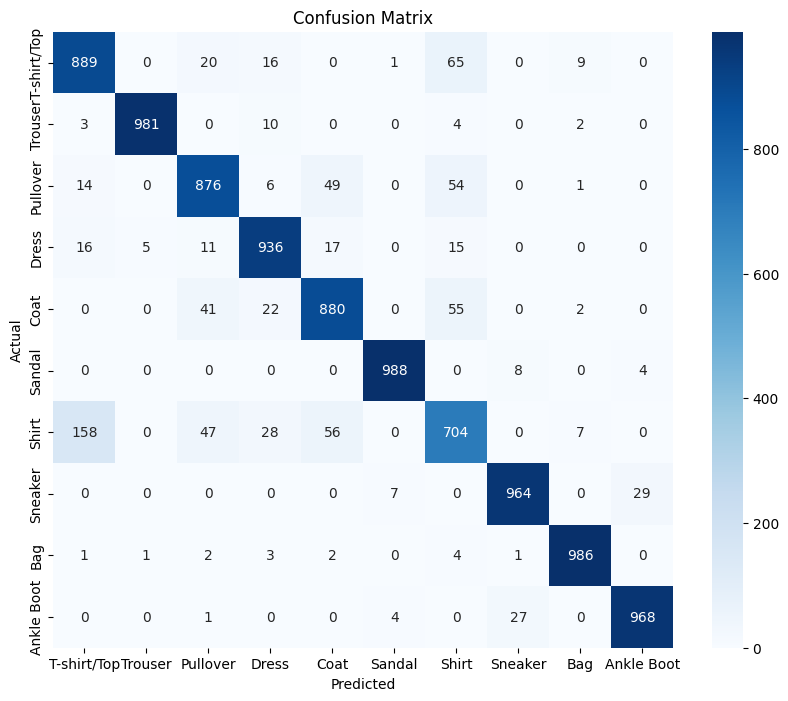

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### SAMPLE IMAGES

#### BEFORE PREDICTIONS

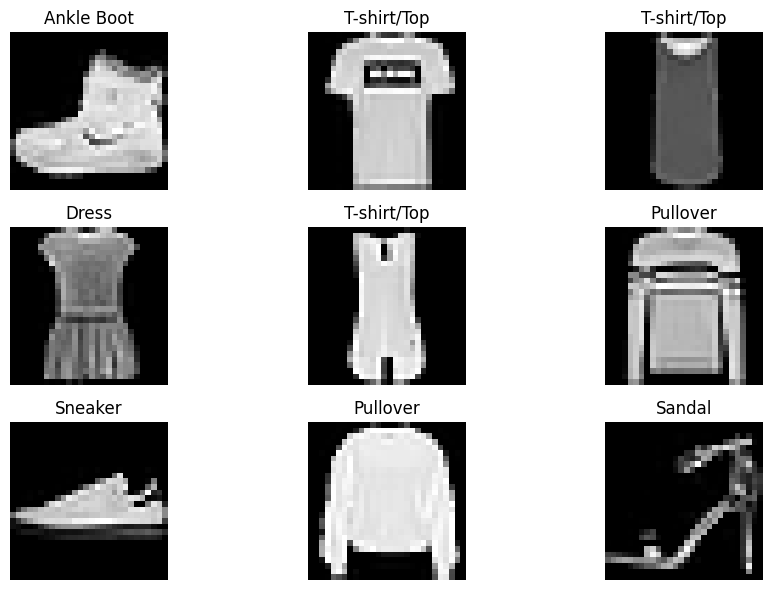

In [16]:
plt.figure(figsize=(10, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### AFTER PREDICTIONS

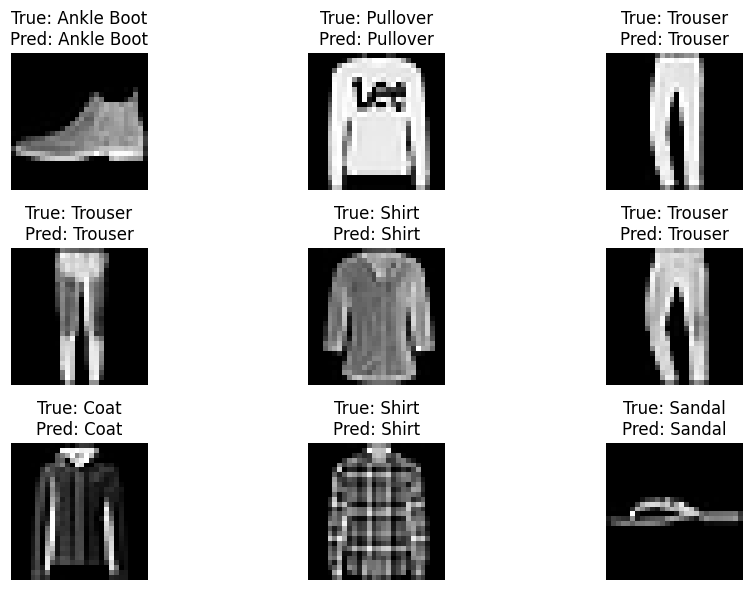

In [20]:
plt.figure(figsize=(10, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(
        "True: " + class_names[y_test[i]] +
        "\nPred: " + class_names[y_pred[i]]
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

### TRAINING CURVES

#### Loss Curve

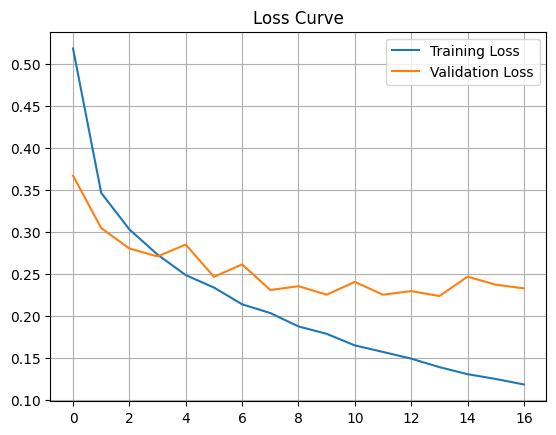

In [18]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

#### Accuracy Curve

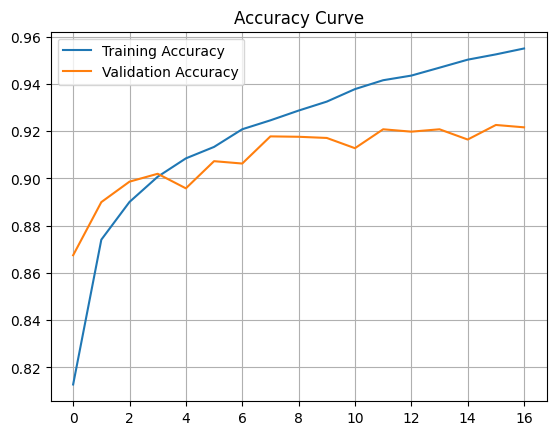

In [19]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

## INSIGHTS

CNN transforms raw pixels → features → classification


**The CNN learns hierarchical patterns:**

1. Early layers → edges and simple shapes
2. Middle layers → object parts
3. Deep layers → full object representation

**Why CNN works well:**

- Convolution reduces parameters
- Weight sharing improves efficiency
- Pooling reduces spatial size
- Softmax outputs probability distribution

**Final conclusion:** Model successfully classifies fashion items with high accuracy using learned visual features.